<a href="https://colab.research.google.com/github/winner-igwe/PINN-Thermal-Modeling/blob/main/PINN_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os


drive.mount('/content/drive')


project_path = '/content/drive/My Drive/PINNs_Project'
if not os.path.exists(project_path):
    os.makedirs(project_path)
    print(f"Created project folder at: {project_path}")
else:
    print(f"Project folder already exists at: {project_path}")


os.chdir(project_path)

Mounted at /content/drive
Project folder already exists at: /content/drive/My Drive/PINNs_Project


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Check if the GPU is on
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Status Report:")
print(f"----------------")
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")

if device.type == 'cuda':
    print("Success! You are running on a Tesla T4 GPU.")
else:
    print("Warning: You are still on CPU. Go to Runtime > Change runtime type.")

Status Report:
----------------
PyTorch Version: 2.10.0+cu128
Device: cuda
Success! You are running on a Tesla T4 GPU.


Starting Training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0: Loss = 0.51502
Epoch 1000: Loss = 0.00017
Epoch 2000: Loss = 0.00005
Epoch 3000: Loss = 0.00004
Epoch 4000: Loss = 0.00010


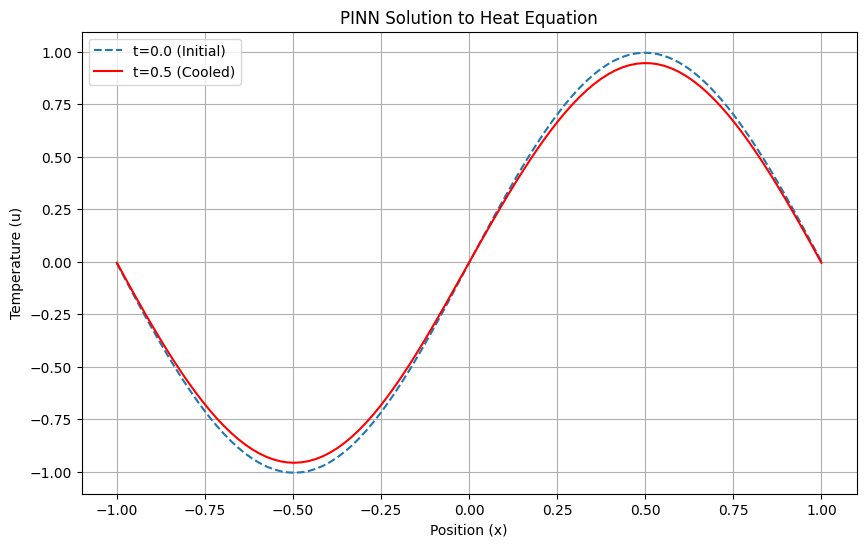

Model saved to Google Drive.


In [3]:

#1 DEFINE THE NEURAL NETWORK
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Simple feed-forward network: 2 inputs (x, t) -> 1 output (Temperature)
        self.net = nn.Sequential(
            nn.Linear(2, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x, t):
        # Combine x and t into a single input tensor
        inputs = torch.cat([x, t], axis=1)
        return self.net(inputs)

# 2 DEFINE THE PHYSICS
def physics_loss(model, x, t):
    """
    Calculates how much the model VIOLATES the Heat Equation.
    Equation: u_t - alpha * u_xx = 0
    """
    alpha = 0.01 # Thermal diffusivity

    # Enable gradient tracking for physics derivatives
    x.requires_grad = True
    t.requires_grad = True

    # Predict Temperature u
    u = model(x, t)

    # First derivatives (du/dx, du/dt)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]

    # Second derivative (d^2u/dx^2)
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    # Residual = u_t - alpha * u_xx
    residual = u_t - (alpha * u_xx)

    return torch.mean(residual ** 2)

# 3 GENERATE TRAINING DATA
# random points in space (x) and time (t) to train the physics
x_physics = torch.rand(2000, 1).to(device) * 2 - 1  # x in [-1, 1]
t_physics = torch.rand(2000, 1).to(device)          # t in [0, 1]

# Boundary Conditions
# Initial Condition: t=0, u = sin(pi*x)
x_bc = torch.rand(500, 1).to(device) * 2 - 1
t_bc = torch.zeros(500, 1).to(device)
u_bc = torch.sin(np.pi * x_bc)

# Wall Conditions: x=-1 and x=1, u = 0 (Cold ends)
x_left = -1 * torch.ones(250, 1).to(device)
t_left = torch.rand(250, 1).to(device)
u_left = torch.zeros(250, 1).to(device)

x_right = 1 * torch.ones(250, 1).to(device)
t_right = torch.rand(250, 1).to(device)
u_right = torch.zeros(250, 1).to(device)

# 4 TRAINING LOOP
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Starting Training...")
for epoch in range(5000):
    optimizer.zero_grad()

    # Loss 1: Physics Loss
    loss_phy = physics_loss(model, x_physics, t_physics)

    # Loss 2: Data Loss
    pred_bc = model(x_bc, t_bc)
    pred_left = model(x_left, t_left)
    pred_right = model(x_right, t_right)

    loss_data = torch.mean((pred_bc - u_bc)**2) + \
                torch.mean((pred_left - u_left)**2) + \
                torch.mean((pred_right - u_right)**2)

    # Total Loss
    total_loss = loss_phy + loss_data
    total_loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss.item():.5f}")

# 5 VISUALIZATION
# Create a grid to visualize the result
x_test = torch.linspace(-1, 1, 100).view(-1, 1).to(device)
t_test = torch.zeros_like(x_test).to(device) # Plot at t=0
u_pred_0 = model(x_test, t_test).detach().cpu().numpy()

t_test_final = torch.ones_like(x_test).to(device) * 0.5 # Plot at t=0.5
u_pred_final = model(x_test, t_test_final).detach().cpu().numpy()

plt.figure(figsize=(10,6))
plt.plot(x_test.cpu().numpy(), u_pred_0, label='t=0.0 (Initial)', linestyle='--')
plt.plot(x_test.cpu().numpy(), u_pred_final, label='t=0.5 (Cooled)', color='red')
plt.title("PINN Solution to Heat Equation")
plt.xlabel("Position (x)")
plt.ylabel("Temperature (u)")
plt.legend()
plt.grid()
plt.show()

# Save the model
torch.save(model.state_dict(), 'model_week1.pth')
print("Model saved to Google Drive.")